# Circuits for Lesson 11 of the Tutorial

The 4 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 11 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.16'

## 1. A low-pass RC (the Bode plot)

In this problem, we draw a Bode plot for the first time: plot v_2 between 10 and 100000 Hz and see the low-pass rolloff — flat, then falling 20 dB per decade with the phase heading for -90°. The Plot card re-solves the circuit at every frequency, which is why it takes the circuit and an answer's name rather than an expression.

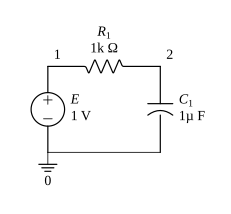

In [3]:
c1 = '''
e,1,0,1
r1,1,2,1000
c1,2,0,1e-6
'''
draw(c1)

In [4]:
r1 = ac(c1, omega=1)
r1.rounded(5)

Result(domain='ac')
  ap_e = -5.0000E-10
  ap_r1 = 5.0000E-10
  i_c1 = 1.0e-9 + 1.0e-6*I
  i_e = -1.0e-9 - 1.0e-6*I
  i_r1 = 1.0e-9 + 1.0e-6*I
  p_e = -5.0000E-10
  p_r1 = 5.0000E-10
  q_e = 5.0000E-7
  q_r1 = 0
  s_c1 = -5.0e-7*I
  s_e = -5.0e-10 + 5.0e-7*I
  s_r1 = 5.0000E-10
  v_1 = 1.0000
  v_2 = 1.0 - 0.001*I
  v_c1 = 1.0 - 0.001*I
  v_e = 1.0000
  v_r1 = 1.0e-6 + 0.001*I
  z_e = 1000.0 - 1.0e+6*I

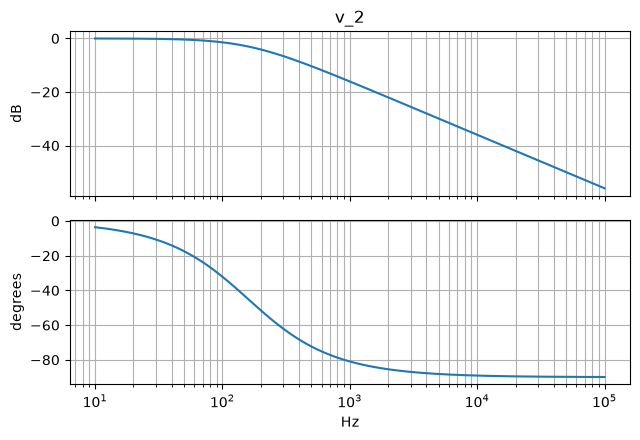

In [5]:
f, mag, phase = bode_samples(c1, 'v_2', 10, 100000, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('v_2'); plt.tight_layout()

## 2. AS7's Example 14.7 (series resonance)

Find the resonance frequency of the series RLC — solve im(ze) = 0 with w > 0 and real solutions only: 50000 rad/s. For the bandwidth frequencies, solve abs(ze) = sqrt(2)*2 with w<50000 and then w>50000: 49010 and 51010 rad/s.

![The circuit of AS7's Example 14.7 (series resonance)](https://learn.symbulator.com/assets/circuit/as7e1407.png)

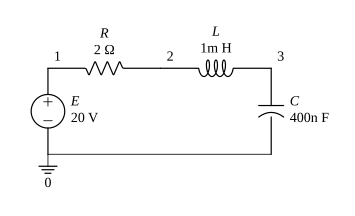

In [6]:
c2 = '''
e,1,0,20
r,1,2,2
l,2,3,1'm
c,3,0,.4'u
'''
draw(c2)

In [7]:
r2 = ac(c2, omega='w')
r2.rounded(5)

Result(domain='ac')
  ap_e = 2.0e+5*im(conjugate(w)/(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9))
  ap_r = -4.0e+8*re(1/((-w**2 + 2000.0*I*w + 2.5e+9)*(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9)))*Abs(w)**2
  i_c = 20000.0*I*w/(-w**2 + 2000.0*I*w + 2.5e+9)
  i_e = -20000.0*I*w/(-w**2 + 2000.0*I*w + 2.5e+9)
  i_l = 20000.0*I*w/(-w**2 + 2000.0*I*w + 2.5e+9)
  i_r = 20000.0*I*w/(-w**2 + 2000.0*I*w + 2.5e+9)
  p_e = 2.0e+5*im(conjugate(w)/(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9))
  p_r = -4.0e+8*re(1/((-w**2 + 2000.0*I*w + 2.5e+9)*(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9)))*Abs(w)**2
  q_e = -2.0e+5*re(conjugate(w)/(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9))
  q_r = -4.0e+8*im(1/((-w**2 + 2000.0*I*w + 2.5e+9)*(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9)))*Abs(w)**2
  s_c = 5.0e+14*I*conjugate(w)/((-w**2 + 2000.0*I*w + 2.5e+9)*(conjugate(w)**2 + 2000.0*I*conjugate(w) - 2.5e+9))
  s_e = -2.0e+5*I*conjugate(w)/(conjugate(w)**2 + 2000.0*I*conjugate

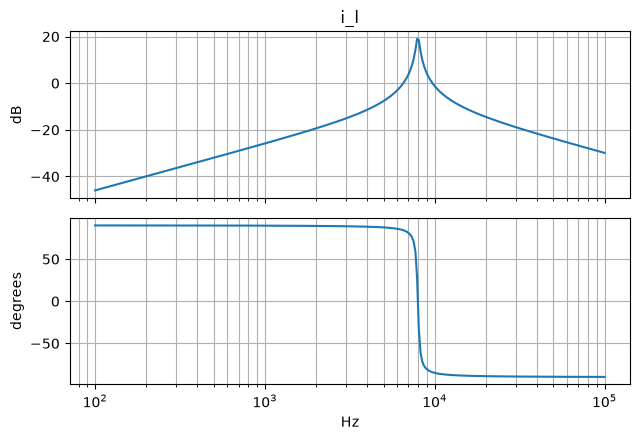

In [8]:
f, mag, phase = bode_samples(c2, 'i_l', 100, 100000, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

*In the app this entry also uses Solve, which this notebook does not reproduce yet.*

## 3. AS7's Example 14.8 (parallel resonance)

Find the resonance frequency of the parallel RLC: 25000 rad/s. The chapter uses im(ie) rather than im(ze) here because the calculator's numerical search could not find so sharp a peak. Version 9 solves symbolically and would manage either, but the equation says something true: at resonance the source's current is in phase with its voltage.

![The circuit of AS7's Example 14.8 (parallel resonance)](https://learn.symbulator.com/assets/circuit/as7e1408.png)

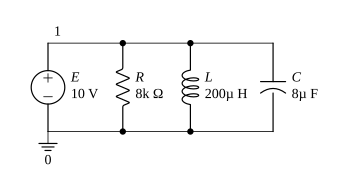

In [9]:
c3 = '''
e,1,0,10
r,1,0,8'k
l,1,0,.2'm
c,1,0,8'u
'''
draw(c3)

In [10]:
r3 = ac(c3, omega='w')
r3.rounded(5)

Result(domain='ac')
  ap_e = ((re(w)**2 + im(w)**2)*(0.0004*im(w) - 0.00625) + 2.5e+5*im(w))/(re(w)**2 + im(w)**2)
  ap_r = 0.0062500
  i_c = 8.0e-5*I*w
  i_e = -8.0e-5*I*w - 0.00125 + 50000.0*I/w
  i_l = -50000.0*I/w
  i_r = 0.0012500
  p_e = ((re(w)**2 + im(w)**2)*(0.0004*im(w) - 0.00625) + 2.5e+5*im(w))/(re(w)**2 + im(w)**2)
  p_r = 0.0062500
  q_e = (0.0004*re(w)**2 + 0.0004*im(w)**2 - 2.5e+5)*re(w)/(re(w)**2 + im(w)**2)
  q_r = 0
  s_c = -0.0004*I*conjugate(w)
  s_e = 0.0004*I*conjugate(w) - 0.00625 - 2.5e+5*I/conjugate(w)
  s_l = 2.5e+5*I/conjugate(w)
  s_r = 0.0062500
  v_1 = 10.000
  v_c = 10.000
  v_e = 10.000
  v_l = 10.000
  v_r = 10.000
  z_e = 10.0*w/(w*(8.0e-5*I*w + 0.00125) - 50000.0*I)

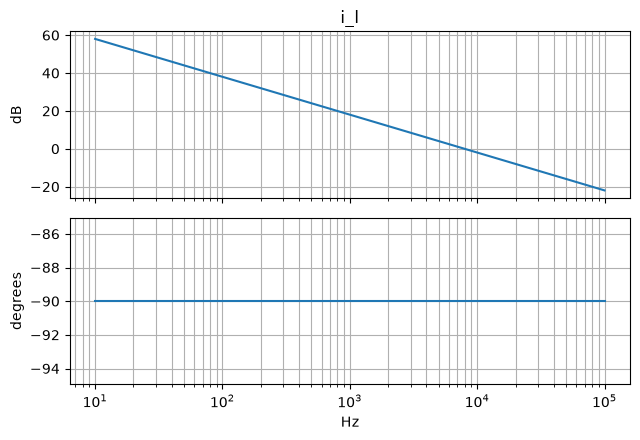

In [11]:
f, mag, phase = bode_samples(c3, 'i_l', 10, 100000, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

*In the app this entry also uses Solve, which this notebook does not reproduce yet.*

## 4. AS7's Example 14.9 (resonance from a node voltage)

Determine the resonant frequency of the circuit: solve im(v1) = 0 with w > 0 and real solutions only, which gives 2 rad/s.

![The circuit of AS7's Example 14.9 (resonance from a node voltage)](https://learn.symbulator.com/assets/circuit/as7e1409.png)

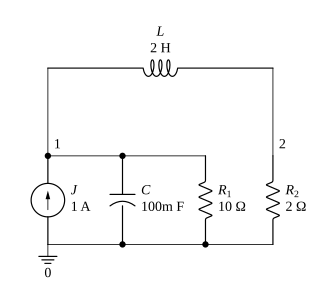

In [12]:
c4 = '''
j,0,1,1
c,1,0,.1
r1,1,0,10
l,1,2,2
r2,2,0,2
'''
draw(c4)

In [13]:
r4 = ac(c4, omega='w')
r4.rounded(5)

Result(domain='ac')
  ap_j = 5.0*(-(im(w) - 1.0)*(re(w)**2 - im(w)**2 + 2.0*im(w) - 6.0) + (2.0*im(w) - 2.0)*re(w)**2)/((2.0*im(w) - 2.0)**2*re(w)**2 + (re(w)**2 - im(w)**2 + 2.0*im(w) - 6.0)**2)
  ap_r1 = -5.0*(-2.0*im(w) + Abs(w)**2 + 1.0)*re(1/((-w**2 + 2.0*I*w + 6.0)*(conjugate(w)**2 + 2.0*I*conjugate(w) - 6.0)))
  ap_r2 = -25.0*re(1/((-w**2 + 2.0*I*w + 6.0)*(conjugate(w)**2 + 2.0*I*conjugate(w) - 6.0)))
  i_c = 1.0*w*(-w + I)/(-1.0*w**2 + 2.0*I*w + 6.0)
  i_j = 1
  i_l = 5.0/(-w**2 + 2.0*I*w + 6.0)
  i_r1 = (I*w + 1.0)/(-w**2 + 2.0*I*w + 6.0)
  i_r2 = 5.0/(-w**2 + 2.0*I*w + 6.0)
  p_j = 5.0*(-(im(w) - 1.0)*(re(w)**2 - im(w)**2 + 2.0*im(w) - 6.0) + (2.0*im(w) - 2.0)*re(w)**2)/((2.0*im(w) - 2.0)**2*re(w)**2 + (re(w)**2 - im(w)**2 + 2.0*im(w) - 6.0)**2)
  p_r1 = -5.0*(-2.0*im(w) + Abs(w)**2 + 1.0)*re(1/((-w**2 + 2.0*I*w + 6.0)*(conjugate(w)**2 + 2.0*I*conjugate(w) - 6.0)))
  p_r2 = -25.0*re(1/((-w**2 + 2.0*I*w + 6.0)*(conjugate(w)**2 + 2.0*I*conjugate(w) - 6.0)))
  q_j = 5.0*((im(w) 

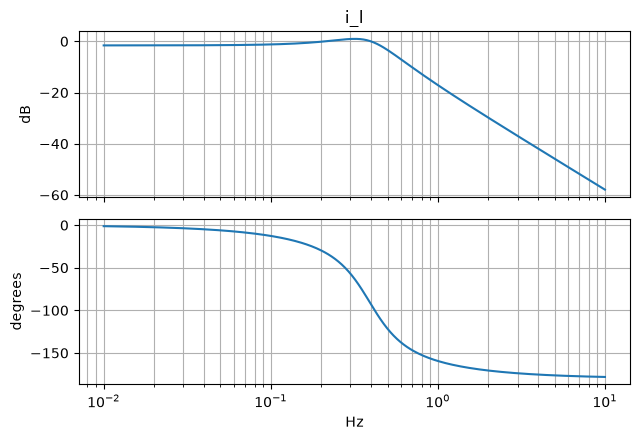

In [14]:
f, mag, phase = bode_samples(c4, 'i_l', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

*In the app this entry also uses Solve, which this notebook does not reproduce yet.*